<a href="https://colab.research.google.com/github/raveesharanamukage/Intelligent-Systems-n-ML/blob/main/Forecast%20Revenue%20By%20MealPeriod/Corrected_LSTM_Dinner_RC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import necessary Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#column_names=['Date','MealPeriod','RevenueCentreName','CheckTotal']
dataset=pd.read_csv('/content/drive/MyDrive/Datasets/hotel/Datasets/Dinner_RevenueCenter_1.csv',parse_dates=['Date'])
print(dataset.head())
print(dataset.info()) #Consice summary of the DataFrame
print(dataset.describe())

        Date MealPeriod RevenueCentreName  CheckTotal
0 2023-01-01     Dinner   RevenueCenter_1      4374.5
1 2023-01-02     Dinner   RevenueCenter_1      3460.0
2 2023-01-03     Dinner   RevenueCenter_1      2735.9
3 2023-01-04     Dinner   RevenueCenter_1      3829.0
4 2023-01-05     Dinner   RevenueCenter_1      3868.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               486 non-null    datetime64[ns]
 1   MealPeriod         486 non-null    object        
 2   RevenueCentreName  486 non-null    object        
 3   CheckTotal         486 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 15.3+ KB
None
                                Date    CheckTotal
count                            486    486.000000
mean   2023-08-31 11:59:59.999999744   2709.006420
min         

In [ ]:
dates=pd.date_range(start='2023-01-01',end='2024-04-30',freq='D')
data=dataset.copy()
#Generate full date range
dates = pd.date_range(start='2023-01-01', end='2024-04-30', freq='D')
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

#Reindex with the full date range
df = data.reindex(dates)

#Rename index to 'Date' to make it clear
df.index.name = 'Date'

#Linear interpolation
df['CheckTotal'] = df['CheckTotal'].interpolate()

df = df.reset_index()
df.head()

,Date,MealPeriod,RevenueCentreName,CheckTotal
0,2023-01-01,Dinner,RevenueCenter_1,4374.5
1,2023-01-02,Dinner,RevenueCenter_1,3460.0
2,2023-01-03,Dinner,RevenueCenter_1,2735.9
3,2023-01-04,Dinner,RevenueCenter_1,3829.0
4,2023-01-05,Dinner,RevenueCenter_1,3868.0


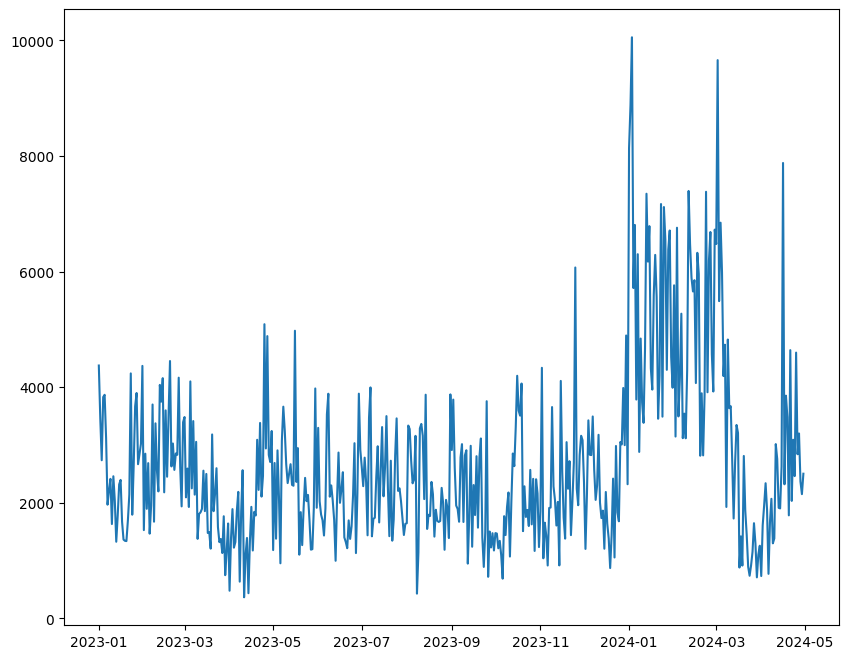

In [ ]:
#Visualize the revenue without considering meal period,revenue centre
plt.figure(figsize=(10,8))
plt.plot(df['Date'],df['CheckTotal'])
plt.show()

Feature Engineering for Dubai LSTM

In [ ]:

df['day_of_week'] = df['Date'].dt.dayofweek  # 0=Mon, 4=Fri, 5=Sat
df['is_weekend'] = df['day_of_week'].isin([4, 5]).astype(int)  # UAE weekend
df['month'] = df['Date'].dt.month
df['is_high_season'] = df['month'].isin([10, 11, 12, 1, 2, 3, 4]).astype(int)  # Oct-Apr




In [ ]:
df['is_ramadan'] = 0
df.loc[(df['Date'].between('2023-03-22', '2023-04-20')) |
       (df['Date'].between('2024-03-10', '2024-04-08')), 'is_ramadan'] = 1

In [ ]:
#dd UAE holidays
from pandas.tseries.holiday import Holiday, nearest_workday
from pandas.tseries.offsets import CustomBusinessDay
holidays = [
    Holiday('UAE National Day', month=12, day=2, observance=nearest_workday),
    # Add Eid al-Fitr, Eid al-Adha, etc., based on lunar calendar
]
df['is_holiday'] = df['Date'].isin(holidays).astype(int)

In [ ]:
#Lag and Rolling Features
df['lag_1'] = df['CheckTotal'].shift(1)  # Previous day
df['lag_7'] = df['CheckTotal'].shift(7)  # Previous week
df['rolling_mean_7'] = df['CheckTotal'].rolling(window=7).mean()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features = ['CheckTotal', 'day_of_week', 'is_weekend','lag_1','is_high_season','rolling_mean_7', 'is_ramadan', 'lag_7']
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)

In [ ]:
df_scaled.dropna(inplace=True)
df_scaled
df_scaled.corr()

,CheckTotal,day_of_week,is_weekend,lag_1,is_high_season,rolling_mean_7,is_ramadan,lag_7
CheckTotal,1.000000,-0.030978,-0.036773,0.607111,0.216540,0.766712,-0.261616,0.450853
day_of_week,-0.030978,1.000000,0.472347,0.000759,0.005272,0.000317,-0.002357,-0.032242
is_weekend,-0.036773,0.472347,1.000000,0.051560,-0.005556,-0.000765,-0.014484,-0.042368
lag_1,0.607111,0.000759,0.051560,1.000000,0.209956,0.789330,-0.255029,0.477643
is_high_season,0.216540,0.005272,-0.005556,0.209956,1.000000,0.253324,0.259242,0.181946
rolling_mean_7,0.766712,0.000317,-0.000765,0.789330,0.253324,1.000000,-0.293254,0.668300
is_ramadan,-0.261616,-0.002357,-0.014484,-0.255029,0.259242,-0.293254,1.000000,-0.165664
lag_7,0.450853,-0.032242,-0.042368,0.477643,0.181946,0.668300,-0.165664,1.000000


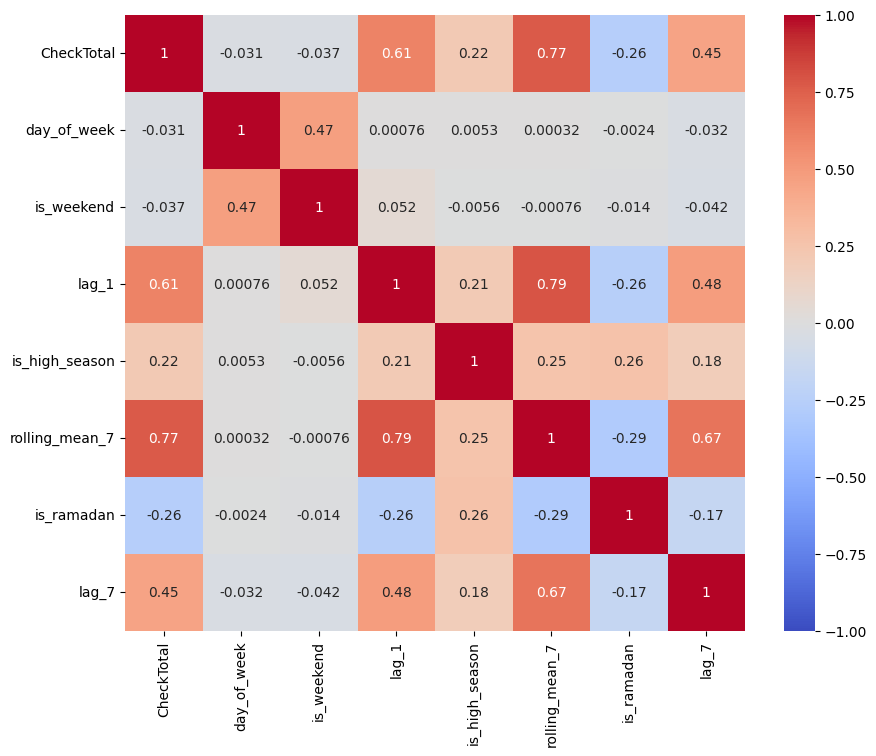

In [ ]:
#Feature Correlation
import seaborn as sns
corr_matrix=df_scaled.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,cmap='coolwarm',annot=True,vmin=-1,vmax=1,)
plt.show()

Sesonality Analysis

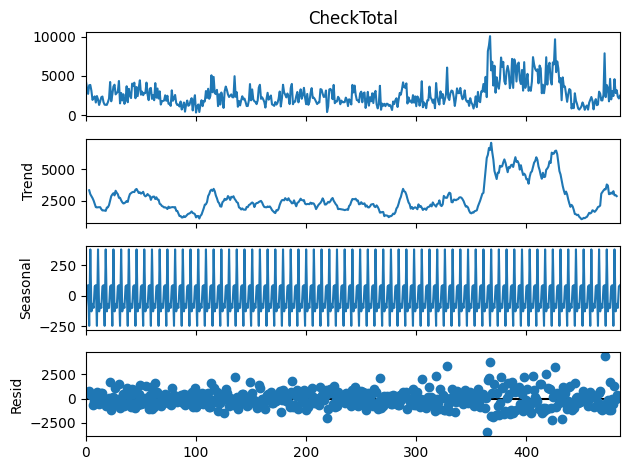

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df['CheckTotal'].dropna(), period=7, model='additive')
decomposition.plot()
plt.show()

### Data Preparation for LSTM

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])  # Predict CheckTotal
    return np.array(X), np.array(y)

seq_length = 7
data = df_scaled.values
X, y = create_sequences(data, seq_length)
X = X.reshape((X.shape[0], X.shape[1], len(features)))  # [samples, timesteps, features]

In [ ]:
#Train test validation split
train_size = int(len(X) * 0.9)
val_size = int(len(X) * 0.1)
X_train, y_train = X[:train_size], y[:train_size]

X_test, y_test = X[train_size:], y[train_size:]

In [ ]:
X_test.shape

(48, 7, 8)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(seq_length, len(features))),
    Dropout(0.3),
    LSTM(50),
    Dropout(0.3),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 100)         │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,851 (288.48 KB)

 Trainable params: 73,851 (288.48 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=50, batch_size=16, callbacks=[early_stopping])

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0588 - val_loss: 0.0145
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0204 - val_loss: 0.0140
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0171 - val_loss: 0.0143
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0202 - val_loss: 0.0146
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0174 - val_loss: 0.0141
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0176 - val_loss: 0.0137
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0134 - val_loss: 0.0151
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0199 - val_loss: 0.0136
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0194 - val_loss: 0.0134
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0176 - val_loss: 0.0150
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0164 - val_loss: 0.0132
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

### Evaluation and Diagnostic

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(np.hstack([y_pred, np.zeros((y_pred.shape[0], len(features)-1))]))[:, 0]
y_test_inv = scaler.inverse_transform(np.hstack([y_test.reshape(-1, 1), np.zeros((y_test.shape[0], len(features)-1))]))[:, 0]

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
r2=r2_score(y_test_inv, y_pred_inv)
print(f'RMSE: {rmse} \nMAE: {mae} \nR²:{r2}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
RMSE: 1099.4863578819904 
MAE: 728.3355690237755 
R²:0.2602491600158433


In [ ]:

test_dates = pd.date_range(start='2024-03-14',periods=X_test.shape[0], freq='D')
future_df = pd.DataFrame({'Date': test_dates})

# Generate future features
future_df['day_of_week'] = future_df['Date'].dt.dayofweek
future_df['is_weekend'] = future_df['day_of_week'].isin([4, 5]).astype(int)
future_df['month'] = future_df['Date'].dt.month
future_df['is_high_season'] = future_df['month'].isin([10, 11, 12, 1, 2, 3, 4]).astype(int)
future_df['is_ramadan'] = 0  # No Ramadan in May-Jul 2024

future_df.set_index('Date', inplace=True)

# Initialize forecast
last_sequence = data[-seq_length:].reshape(1, seq_length, len(features))
forecast = []

# Iterative forecasting
for i in range(len(future_df)):
    pred = model.predict(last_sequence, verbose=0)
    forecast.append(pred[0, 0])

    # Update sequence with new prediction and future features
    # Calculate lag_1, lag_7, and rolling_mean_7 based on the forecast
    lag_1_val = forecast[-1] if len(forecast) > 0 else last_sequence[0, -1, features.index('CheckTotal')]
    lag_7_val = forecast[-7] if len(forecast) >= 7 else last_sequence[0, -7, features.index('CheckTotal')]
    rolling_mean_7_val = np.mean(forecast[-7:]) if len(forecast) >= 7 else np.mean(last_sequence[0, -7:, features.index('CheckTotal')])

    new_row = np.array([pred[0, 0], # CheckTotal (predicted)
                        future_df['day_of_week'].iloc[i],
                        future_df['is_weekend'].iloc[i],
                        lag_1_val, # lag_1 (previous day's forecast)
                        future_df['is_high_season'].iloc[i],
                        rolling_mean_7_val, # rolling_mean_7 (mean of last 7 forecasts)
                        future_df['is_ramadan'].iloc[i],
                        lag_7_val # lag_7 (previous week's forecast)
                        ])
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, :] = new_row

# Inverse transform predictions
forecast_array = np.array(forecast).reshape(-1, 1)
forecast_padded = np.hstack([forecast_array, np.zeros((len(forecast), len(features)-1))])
forecast_inv = scaler.inverse_transform(forecast_padded)[:, 0]

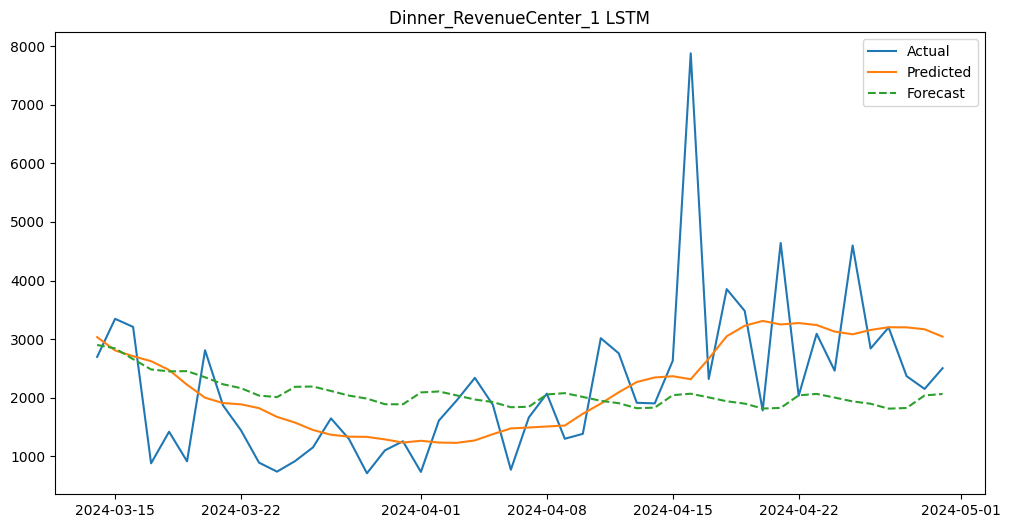

In [ ]:
#Plot test dataset
plt.figure(figsize=(12, 6))
plt.plot(df['Date'].iloc[-len(y_test_inv):], y_test_inv, label='Actual')
plt.plot(df['Date'].iloc[-len(y_pred_inv):], y_pred_inv, label='Predicted')
plt.plot(future_df.index, forecast_inv, label='Forecast', linestyle='--')

name=f'{df["MealPeriod"][0]}_{df["RevenueCentreName"][0]} LSTM'
plt.title(name)
plt.legend()
plt.show()

In [ ]:
# Prepare future dates (May 1, 2024 - Jul 29, 2024)
future_dates = pd.date_range(start='2024-05-01', end='2024-07-29', freq='D')
future_df = pd.DataFrame({'Date': future_dates})

# Generate future features
future_df['day_of_week'] = future_df['Date'].dt.dayofweek
future_df['is_weekend'] = future_df['day_of_week'].isin([4, 5]).astype(int)
future_df['month'] = future_df['Date'].dt.month
future_df['is_high_season'] = future_df['month'].isin([10, 11, 12, 1, 2, 3, 4]).astype(int)
future_df['is_ramadan'] = 0  # No Ramadan in May-Jul 2024

future_df.set_index('Date', inplace=True)

# Initialize forecast
last_sequence = data[-seq_length:].reshape(1, seq_length, len(features))
forecast = []

# Iterative forecasting
for i in range(len(future_df)):
    pred = model.predict(last_sequence, verbose=0)
    forecast.append(pred[0, 0])

    # Update sequence with new prediction and future features
    # Calculate lag_1, lag_7, and rolling_mean_7 based on the forecast
    lag_1_val = forecast[-1] if len(forecast) > 0 else last_sequence[0, -1, features.index('CheckTotal')]
    lag_7_val = forecast[-7] if len(forecast) >= 7 else last_sequence[0, -7, features.index('CheckTotal')]
    rolling_mean_7_val = np.mean(forecast[-7:]) if len(forecast) >= 7 else np.mean(last_sequence[0, -7:, features.index('CheckTotal')])

    new_row = np.array([pred[0, 0], # CheckTotal (predicted)
                        future_df['day_of_week'].iloc[i],
                        future_df['is_weekend'].iloc[i],
                        lag_1_val, # lag_1 (previous day's forecast)
                        future_df['is_high_season'].iloc[i],
                        rolling_mean_7_val, # rolling_mean_7 (mean of last 7 forecasts)
                        future_df['is_ramadan'].iloc[i],
                        lag_7_val # lag_7 (previous week's forecast)
                        ])
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, :] = new_row

# Inverse transform predictions
forecast_array = np.array(forecast).reshape(-1, 1)
forecast_padded = np.hstack([forecast_array, np.zeros((len(forecast), len(features)-1))])
forecast_inv = scaler.inverse_transform(forecast_padded)[:, 0]

In [ ]:
future_da = pd.DataFrame({'Date': future_dates})
future_da['Checktotal']=forecast_inv
future_da


,Date,Checktotal
0,2024-05-01,2899.976775
1,2024-05-02,2819.677965
2,2024-05-03,2671.916020
3,2024-05-04,2407.071757
4,2024-05-05,2162.032267
...,...,...
85,2024-07-25,1311.138256
86,2024-07-26,1254.401658
87,2024-07-27,1139.231729
88,2024-07-28,1136.129195


In [ ]:
file_name=f'{df["MealPeriod"][0]}_{df["RevenueCentreName"][0]} LSTM'
future_da.to_csv(f"/content/drive/MyDrive/Datasets/hotel/LSTM Forecast/{file_name}.csv",index=False)

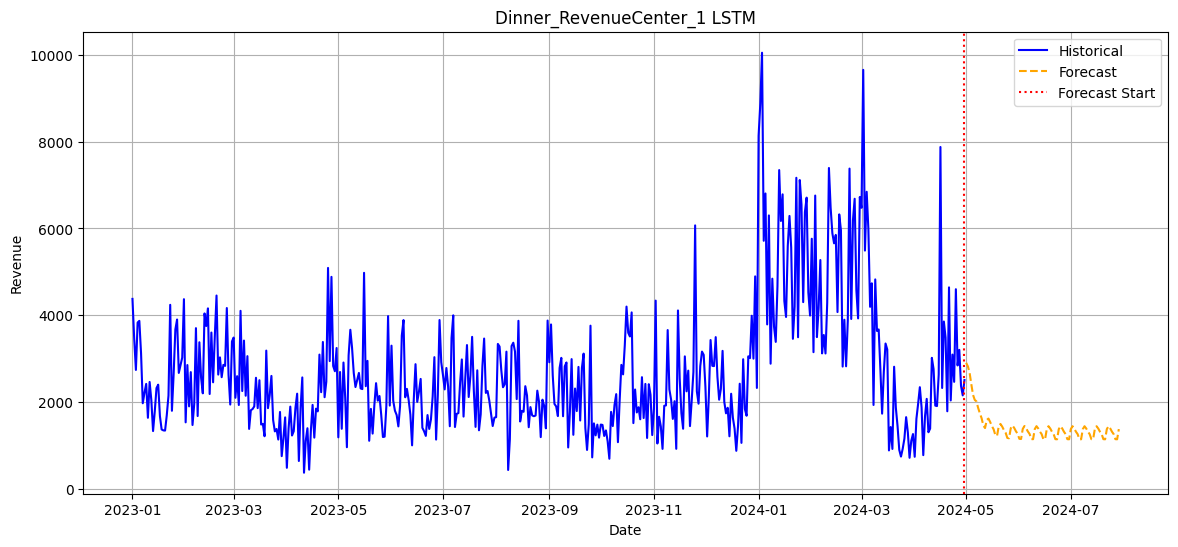

In [ ]:
# Combine historical and forecast data
historical_df = df[['Date', 'CheckTotal']].set_index('Date')
forecast_df = pd.DataFrame({'CheckTotal': forecast_inv}, index=future_dates)
combined_df = pd.concat([historical_df, forecast_df])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(historical_df.index, historical_df['CheckTotal'], label='Historical', color='blue')
plt.plot(forecast_df.index, forecast_df['CheckTotal'], label='Forecast', color='orange', linestyle='--')
plt.axvline(x=pd.to_datetime('2024-04-30'), color='red', linestyle=':', label='Forecast Start')
name=f'{df["MealPeriod"][0]}_{df["RevenueCentreName"][0]} LSTM'
plt.title(name)
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()